In [1]:
!nvidia-smi

Tue Sep 22 13:32:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.60                 KMD Version: 610.60        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P5             18W /  575W |    3102MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install torch==2.13.0 torchvision==0.28.0 --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import subprocess

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in this Jupyter kernel.")

gpu_name = torch.cuda.get_device_name(0)

print("GPU:", gpu_name)

if "5090" not in gpu_name and "4090" not in gpu_name:
    raise RuntimeError(
        f"Unsupported GPU detected: {gpu_name}. "
        "This assignment requires RTX 4090 or RTX 5090."
    )

print("\nValid GPU for assignment.")

result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True,
    check=True
)

print("\nNVIDIA SMI:\n")
print(result.stdout)

PyTorch version: 2.13.0+cu132
CUDA available: True
CUDA runtime: 13.2
GPU: NVIDIA GeForce RTX 5090

Valid GPU for assignment.

NVIDIA SMI:

Tue Sep 22 13:32:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.60                 KMD Version: 610.60        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P5             19W /  575W |    3110MiB /  32607MiB |      0%      Default |


In [4]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU detected.")

gpu_name = torch.cuda.get_device_name(0)

print("Detected GPU:", gpu_name)

if "4090" in gpu_name:
    print("Valid GPU for assignment: RTX 4090")

elif "5090" in gpu_name:
    print("Valid GPU for assignment: RTX 5090")

else:
    raise RuntimeError(
        f"Wrong GPU for this assignment: {gpu_name}. "
        "You need an RTX 4090 or RTX 5090."
    )

Detected GPU: NVIDIA GeForce RTX 5090
Valid GPU for assignment: RTX 5090


In [5]:
%pip install --upgrade pip
%pip install numpy pandas matplotlib
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import gc
import csv
import math
import time
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

In [7]:
OUTPUT_DIR = Path("hw2_5_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type != "cuda":
    raise RuntimeError("A CUDA GPU is required for this assignment.")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cu132
CUDA available: True
CUDA runtime: 13.2
GPU: NVIDIA GeForce RTX 5090


In [8]:
smi_query = subprocess.run(
    ["nvidia-smi", "-q"],
    capture_output=True,
    text=True,
    check=True
)

nvidia_smi_text = smi_query.stdout

with open(OUTPUT_DIR / "nvidia_smi_q.txt", "w") as f:
    f.write(nvidia_smi_text)

print(nvidia_smi_text[:5000])


==============NVSMI LOG==============

Timestamp                                              : Tue Sep 22 13:32:47 2026
Driver Version                                         : 610.60 [Deprecated; will be removed in CUDA 14.0. Use KMD Version instead]
CUDA Version                                           : 13.3 [Deprecated; will be removed in CUDA 14.0. Use CUDA UMD Version instead]
KMD Version                                            : 610.60
CUDA UMD Version                                       : 13.3

Attached GPUs                                          : 1
GPU 00000000:01:00.0
    Product Name                                       : NVIDIA GeForce RTX 5090
    Product Brand                                      : GeForce
    Product Architecture                               : Blackwell
    Display Mode                                       : Requested functionality has been deprecated
    Display Attached                                   : Yes
    Display Active           

In [9]:
uuid_result = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=uuid,name,driver_version,memory.total,power.limit",
        "--format=csv,noheader,nounits"
    ],
    capture_output=True,
    text=True,
    check=True
)

gpu_uuid, gpu_name, driver_version, vram_mb, power_limit_w = [
    item.strip() for item in uuid_result.stdout.strip().split(",")
]

print("GPU UUID:", gpu_uuid)
print("GPU name:", gpu_name)
print("Driver version:", driver_version)
print("CUDA runtime:", torch.version.cuda)
print("VRAM MB:", vram_mb)
print("Power limit W:", power_limit_w)

GPU UUID: GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
GPU name: NVIDIA GeForce RTX 5090
Driver version: 610.60
CUDA runtime: 13.2
VRAM MB: 32607
Power limit W: 575.00


In [10]:
gpu_name_lower = gpu_name.lower()

if "4090" in gpu_name_lower:
    GPU_ARCHITECTURE = "Ada Lovelace"
    GPU_MEMORY_TYPE = "GDDR6X"
    GPU_MEMORY_BANDWIDTH_GB_S = 1008.0
    GPU_TENSOR_CORE_GENERATION = "4th Generation"

    THEORETICAL_TFLOPS = {
        "FP32": 82.6,
        "TF32": 82.6,
        "FP16": 165.2,
        "BF16": 165.2,
    }

elif "5090" in gpu_name_lower:
    GPU_ARCHITECTURE = "Blackwell"
    GPU_MEMORY_TYPE = "GDDR7"

    GPU_MEMORY_BANDWIDTH_GB_S = 1792.0
    GPU_TENSOR_CORE_GENERATION = "5th Generation"

    THEORETICAL_TFLOPS = {
        "FP32": 104.8,
        "TF32": 209.5,
        "FP16": 419.0,
        "BF16": 419.0,
    }

else:
    raise RuntimeError(
        f"Unsupported GPU detected: {gpu_name}. "
        "This assignment expects RTX 4090 or RTX 5090."
    )

print("Architecture:", GPU_ARCHITECTURE)
print("Memory type:", GPU_MEMORY_TYPE)
print("Memory bandwidth GB/s:", GPU_MEMORY_BANDWIDTH_GB_S)
print("Tensor Core generation:", GPU_TENSOR_CORE_GENERATION)
print("Theoretical peaks:", THEORETICAL_TFLOPS)

Architecture: Blackwell
Memory type: GDDR7
Memory bandwidth GB/s: 1792.0
Tensor Core generation: 5th Generation
Theoretical peaks: {'FP32': 104.8, 'TF32': 209.5, 'FP16': 419.0, 'BF16': 419.0}


In [11]:
provenance = {
    "gpu_uuid": gpu_uuid,
    "gpu_name": gpu_name,
    "driver_version": driver_version,
    "cuda_runtime": torch.version.cuda,
    "vram_mb": float(vram_mb),
    "power_limit_w": float(power_limit_w),
    "architecture": GPU_ARCHITECTURE,
    "memory_type": GPU_MEMORY_TYPE,
    "memory_bandwidth_gb_s": GPU_MEMORY_BANDWIDTH_GB_S,
    "tensor_core_generation": GPU_TENSOR_CORE_GENERATION,
}

with open(OUTPUT_DIR / "provenance.json", "w") as f:
    json.dump(provenance, f, indent=4)

provenance

{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517',
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'driver_version': '610.60',
 'cuda_runtime': '13.2',
 'vram_mb': 32607.0,
 'power_limit_w': 575.0,
 'architecture': 'Blackwell',
 'memory_type': 'GDDR7',
 'memory_bandwidth_gb_s': 1792.0,
 'tensor_core_generation': '5th Generation'}

In [12]:
def cuda_sync():
    torch.cuda.synchronize()


def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [13]:
def benchmark_matmul(
    n,
    precision,
    warmup=10,
    repetitions=30
):
    clear_gpu()

    if precision == "FP32":
        dtype = torch.float32
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.set_float32_matmul_precision("highest")

    elif precision == "TF32":
        dtype = torch.float32
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.set_float32_matmul_precision("high")

    elif precision == "FP16":
        dtype = torch.float16

    elif precision == "BF16":
        dtype = torch.bfloat16

    else:
        raise ValueError(f"Unknown precision: {precision}")

    a = torch.randn(
        n,
        n,
        device=device,
        dtype=dtype
    )

    b = torch.randn(
        n,
        n,
        device=device,
        dtype=dtype
    )

    for _ in range(warmup):
        c = torch.matmul(a, b)

    cuda_sync()

    times_ms = []

    for _ in range(repetitions):
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()
        c = torch.matmul(a, b)
        end.record()

        cuda_sync()

        times_ms.append(start.elapsed_time(end))

    median_ms = float(np.median(times_ms))
    mean_ms = float(np.mean(times_ms))
    std_ms = float(np.std(times_ms))

    flops = 2.0 * (n ** 3)

    achieved_tflops = flops / (median_ms / 1000.0) / 1e12

    theoretical = THEORETICAL_TFLOPS[precision]

    percent_peak = (
        achieved_tflops / theoretical
    ) * 100.0

    result = {
        "gpu_uuid": gpu_uuid,
        "gpu_name": gpu_name,
        "N": n,
        "precision": precision,
        "warmup": warmup,
        "repetitions": repetitions,
        "median_ms": median_ms,
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "achieved_tflops": achieved_tflops,
        "theoretical_tflops": theoretical,
        "percent_peak": percent_peak,
    }

    del a
    del b
    del c

    clear_gpu()

    return result

In [14]:
matrix_sizes = [
    1024,
    4096,
    8192,
    16384,
]

precisions = [
    "FP32",
    "TF32",
    "FP16",
    "BF16",
]

matmul_results = []

for precision in precisions:
    for n in matrix_sizes:
        try:
            print(
                f"Running {precision}, N={n}"
            )

            result = benchmark_matmul(
                n=n,
                precision=precision,
                warmup=10,
                repetitions=30
            )

            matmul_results.append(result)

            print(result)

        except torch.cuda.OutOfMemoryError:
            print(
                f"OOM for {precision}, N={n}"
            )

            clear_gpu()

Running FP32, N=1024
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'gpu_name': 'NVIDIA GeForce RTX 5090', 'N': 1024, 'precision': 'FP32', 'warmup': 10, 'repetitions': 30, 'median_ms': 0.0671359971165657, 'mean_ms': 0.07517013313869635, 'std_ms': 0.01990683616313034, 'achieved_tflops': 31.987067150747833, 'theoretical_tflops': 104.8, 'percent_peak': 30.522010640026558}
Running FP32, N=4096
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'gpu_name': 'NVIDIA GeForce RTX 5090', 'N': 4096, 'precision': 'FP32', 'warmup': 10, 'repetitions': 30, 'median_ms': 2.1120959520339966, 'mean_ms': 2.0823541283607483, 'std_ms': 0.07117016522980636, 'achieved_tflops': 65.07230570639709, 'theoretical_tflops': 104.8, 'percent_peak': 62.09189475801249}
Running FP32, N=8192
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'gpu_name': 'NVIDIA GeForce RTX 5090', 'N': 8192, 'precision': 'FP32', 'warmup': 10, 'repetitions': 30, 'median_ms': 16.58414363861084, 'mean_ms': 16.66416962941

In [15]:
matmul_df = pd.DataFrame(matmul_results)

matmul_df.to_csv(
    OUTPUT_DIR / "part_b_matmul_results.csv",
    index=False
)

matmul_df

,gpu_uuid,gpu_name,N,precision,warmup,repetitions,median_ms,mean_ms,std_ms,achieved_tflops,theoretical_tflops,percent_peak
0,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,1024,FP32,10,30,0.067136,0.075170,0.019907,31.987067,104.8,30.522011
1,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,4096,FP32,10,30,2.112096,2.082354,0.071170,65.072306,104.8,62.091895
2,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,8192,FP32,10,30,16.584144,16.664170,0.481440,66.298969,104.8,63.262375
3,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,16384,FP32,10,30,133.488098,133.979975,1.997032,65.894212,104.8,62.876156
4,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,1024,TF32,10,30,0.117696,0.133331,0.054688,18.246021,209.5,8.709318
5,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,4096,TF32,10,30,1.382592,1.483793,0.545727,99.406731,209.5,47.449514
6,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,8192,TF32,10,30,9.770976,9.760763,0.072930,112.528336,209.5,53.712810
7,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,16384,TF32,10,30,78.203011,77.706388,1.158853,112.477678,209.5,53.688629
8,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,1024,FP16,10,30,0.037872,0.036987,0.003617,56.703730,419.0,13.533110
9,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,NVIDIA GeForce RTX 5090,4096,FP16,10,30,0.669200,0.679052,0.046044,205.378002,419.0,49.016230


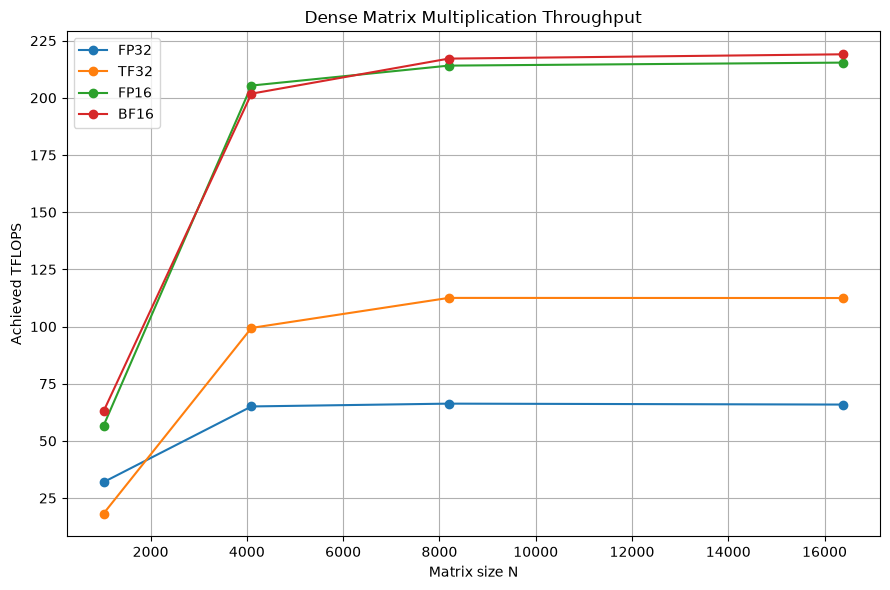

In [16]:
plt.figure(figsize=(9, 6))

for precision in precisions:
    subset = matmul_df[
        matmul_df["precision"] == precision
    ]

    plt.plot(
        subset["N"],
        subset["achieved_tflops"],
        marker="o",
        label=precision
    )

plt.xlabel("Matrix size N")
plt.ylabel("Achieved TFLOPS")
plt.title("Dense Matrix Multiplication Throughput")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "part_b_tflops_vs_matrix_size.png",
    dpi=200
)

plt.show()

In [17]:
plateau_rows = []

for precision in precisions:
    subset = matmul_df[
        matmul_df["precision"] == precision
    ].sort_values("N")

    if len(subset) == 0:
        continue

    max_perf = subset["achieved_tflops"].max()

    threshold = 0.95 * max_perf

    plateau_candidates = subset[
        subset["achieved_tflops"] >= threshold
    ]

    plateau_n = int(
        plateau_candidates.iloc[0]["N"]
    )

    plateau_rows.append(
        {
            "precision": precision,
            "plateau_N": plateau_n,
            "max_measured_tflops": max_perf,
        }
    )

plateau_df = pd.DataFrame(plateau_rows)

plateau_df

,precision,plateau_N,max_measured_tflops
0,FP32,4096,66.298969
1,TF32,8192,112.528336
2,FP16,4096,215.411179
3,BF16,8192,219.046206


In [18]:
fp8_test_result = {
    "gpu_uuid": gpu_uuid,
    "gpu_name": gpu_name,
    "attempted": True,
    "available": False,
    "message": "",
}

try:
    float8_dtype = torch.float8_e4m3fn

    x = torch.randn(
        1024,
        1024,
        device=device,
        dtype=torch.float16
    ).to(float8_dtype)

    y = torch.randn(
        1024,
        1024,
        device=device,
        dtype=torch.float16
    ).to(float8_dtype)

    z = torch.matmul(x, y)

    cuda_sync()

    fp8_test_result["available"] = True
    fp8_test_result["message"] = (
        f"FP8 matmul succeeded. "
        f"Output dtype: {z.dtype}"
    )

except Exception as e:
    fp8_test_result["message"] = (
        f"FP8 attempt failed with: "
        f"{type(e).__name__}: {str(e)}"
    )

print(fp8_test_result)

{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'gpu_name': 'NVIDIA GeForce RTX 5090', 'attempted': True, 'available': False, 'message': 'FP8 attempt failed with: NotImplementedError: "addmm_cuda" not implemented for \'Float8_e4m3fn\''}


In [19]:
with open(
    OUTPUT_DIR / "part_b_lower_precision_test.json",
    "w"
) as f:
    json.dump(
        fp8_test_result,
        f,
        indent=4
    )

In [20]:
def benchmark_memory_copy(
    num_elements=256_000_000,
    warmup=10,
    repetitions=30
):
    clear_gpu()

    dtype = torch.float32

    x = torch.randn(
        num_elements,
        device=device,
        dtype=dtype
    )

    y = torch.empty_like(x)

    for _ in range(warmup):
        y.copy_(x)

    cuda_sync()

    times_ms = []

    for _ in range(repetitions):
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()

        y.copy_(x)

        end.record()

        cuda_sync()

        times_ms.append(
            start.elapsed_time(end)
        )

    median_ms = float(
        np.median(times_ms)
    )

    bytes_per_element = x.element_size()

    total_bytes = (
        num_elements
        * bytes_per_element
        * 2
    )

    effective_bandwidth = (
        total_bytes
        / (median_ms / 1000.0)
        / 1e9
    )

    percent_spec = (
        effective_bandwidth
        / GPU_MEMORY_BANDWIDTH_GB_S
        * 100.0
    )

    result = {
        "gpu_uuid": gpu_uuid,
        "num_elements": num_elements,
        "dtype": str(dtype),
        "median_ms": median_ms,
        "bytes_moved": total_bytes,
        "effective_bandwidth_gb_s": effective_bandwidth,
        "percent_spec_bandwidth": percent_spec,
    }

    del x
    del y

    clear_gpu()

    return result

In [21]:
memory_result = benchmark_memory_copy()

memory_result

{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517',
 'num_elements': 256000000,
 'dtype': 'torch.float32',
 'median_ms': 1.3632799983024597,
 'bytes_moved': 2048000000,
 'effective_bandwidth_gb_s': 1502.2592589564472,
 'percent_spec_bandwidth': 83.83143186140887}

In [22]:
def arithmetic_intensity_copy(dtype_bytes=4):
    flops = 0.0

    bytes_moved = (
        dtype_bytes
        + dtype_bytes
    )

    return flops / bytes_moved


def arithmetic_intensity_add(dtype_bytes=4):
    flops = 1.0

    bytes_moved = (
        dtype_bytes
        + dtype_bytes
        + dtype_bytes
    )

    return flops / bytes_moved


def arithmetic_intensity_matmul(n, dtype_bytes=2):
    flops = 2.0 * n ** 3

    bytes_moved = (
        3.0
        * n ** 2
        * dtype_bytes
    )

    return flops / bytes_moved

In [23]:
roofline_results = {
    "copy_flops_per_byte": arithmetic_intensity_copy(
        dtype_bytes=4
    ),
    "elementwise_add_flops_per_byte": arithmetic_intensity_add(
        dtype_bytes=4
    ),
    "matmul_8192_fp16_flops_per_byte": arithmetic_intensity_matmul(
        n=8192,
        dtype_bytes=2
    ),
}

roofline_results

{'copy_flops_per_byte': 0.0,
 'elementwise_add_flops_per_byte': 0.08333333333333333,
 'matmul_8192_fp16_flops_per_byte': 2730.6666666666665}

In [24]:
compute_result = benchmark_matmul(
    n=8192,
    precision="FP16",
    warmup=10,
    repetitions=30
)

part_c_df = pd.DataFrame(
    [
        {
            "gpu_uuid": gpu_uuid,
            "operation": "memory_copy",
            "arithmetic_intensity_flops_per_byte": roofline_results[
                "copy_flops_per_byte"
            ],
            "effective_bandwidth_gb_s": memory_result[
                "effective_bandwidth_gb_s"
            ],
            "achieved_tflops": np.nan,
            "roofline_side": "memory_bound",
        },
        {
            "gpu_uuid": gpu_uuid,
            "operation": "8192_fp16_matmul",
            "arithmetic_intensity_flops_per_byte": roofline_results[
                "matmul_8192_fp16_flops_per_byte"
            ],
            "effective_bandwidth_gb_s": np.nan,
            "achieved_tflops": compute_result[
                "achieved_tflops"
            ],
            "roofline_side": "compute_bound",
        },
    ]
)

part_c_df.to_csv(
    OUTPUT_DIR / "part_c_roofline_results.csv",
    index=False
)

part_c_df

,gpu_uuid,operation,arithmetic_intensity_flops_per_byte,effective_bandwidth_gb_s,achieved_tflops,roofline_side
0,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,memory_copy,0.000000,1502.259259,NaN,memory_bound
1,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,8192_fp16_matmul,2730.666667,NaN,213.913438,compute_bound


In [25]:
ATTENTION_BATCH_SIZE = 1
ATTENTION_HEAD_DIM = 64

print(
    "Attention batch size:",
    ATTENTION_BATCH_SIZE
)

print(
    "Attention head dimension:",
    ATTENTION_HEAD_DIM
)

Attention batch size: 1
Attention head dimension: 64


In [26]:
def naive_attention(
    q,
    k,
    v
):
    scale = 1.0 / math.sqrt(
        q.shape[-1]
    )

    scores = torch.matmul(
        q,
        k.transpose(-2, -1)
    )

    scores = scores * scale

    seq_len = q.shape[-2]

    mask = torch.triu(
        torch.ones(
            seq_len,
            seq_len,
            device=q.device,
            dtype=torch.bool
        ),
        diagonal=1
    )

    scores = scores.masked_fill(
        mask,
        float("-inf")
    )

    probs = torch.softmax(
        scores,
        dim=-1
    )

    output = torch.matmul(
        probs,
        v
    )

    return output

In [27]:
def fused_attention(
    q,
    k,
    v
):
    return F.scaled_dot_product_attention(
        q,
        k,
        v,
        attn_mask=None,
        dropout_p=0.0,
        is_causal=True
    )

In [28]:
def benchmark_attention(
    seq_len,
    implementation="naive",
    dtype=torch.float16,
    warmup=5,
    repetitions=20
):
    clear_gpu()

    q = torch.randn(
        ATTENTION_BATCH_SIZE,
        1,
        seq_len,
        ATTENTION_HEAD_DIM,
        device=device,
        dtype=dtype
    )

    k = torch.randn_like(q)
    v = torch.randn_like(q)

    attention_fn = (
        naive_attention
        if implementation == "naive"
        else fused_attention
    )

    for _ in range(warmup):
        out = attention_fn(
            q,
            k,
            v
        )

    cuda_sync()

    torch.cuda.reset_peak_memory_stats()

    times_ms = []

    for _ in range(repetitions):
        start = torch.cuda.Event(
            enable_timing=True
        )

        end = torch.cuda.Event(
            enable_timing=True
        )

        start.record()

        out = attention_fn(
            q,
            k,
            v
        )

        end.record()

        cuda_sync()

        times_ms.append(
            start.elapsed_time(end)
        )

    peak_memory_bytes = (
        torch.cuda.max_memory_allocated()
    )

    result = {
        "gpu_uuid": gpu_uuid,
        "implementation": implementation,
        "sequence_length": seq_len,
        "batch_size": ATTENTION_BATCH_SIZE,
        "head_dim": ATTENTION_HEAD_DIM,
        "dtype": str(dtype),
        "median_latency_ms": float(
            np.median(times_ms)
        ),
        "mean_latency_ms": float(
            np.mean(times_ms)
        ),
        "peak_memory_gb": (
            peak_memory_bytes / 1e9
        ),
        "success": True,
    }

    del q
    del k
    del v
    del out

    clear_gpu()

    return result

In [29]:
attention_sequence_lengths = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
]

naive_attention_results = []

for seq_len in attention_sequence_lengths:
    print(
        f"Naive attention, sequence length {seq_len}"
    )

    try:
        result = benchmark_attention(
            seq_len=seq_len,
            implementation="naive",
            dtype=torch.float16,
            warmup=5,
            repetitions=20
        )

        naive_attention_results.append(
            result
        )

        print(result)

    except torch.cuda.OutOfMemoryError:
        clear_gpu()

        result = {
            "gpu_uuid": gpu_uuid,
            "implementation": "naive",
            "sequence_length": seq_len,
            "batch_size": ATTENTION_BATCH_SIZE,
            "head_dim": ATTENTION_HEAD_DIM,
            "dtype": "torch.float16",
            "median_latency_ms": np.nan,
            "mean_latency_ms": np.nan,
            "peak_memory_gb": np.nan,
            "success": False,
        }

        naive_attention_results.append(
            result
        )

        print(
            f"OOM at sequence length {seq_len}"
        )

Naive attention, sequence length 512
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'naive', 'sequence_length': 512, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.5872800052165985, 'mean_latency_ms': 0.5713903948664665, 'peak_memory_gb': 0.037289984, 'success': True}
Naive attention, sequence length 1024
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'naive', 'sequence_length': 1024, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.17536000162363052, 'mean_latency_ms': 0.17766079902648926, 'peak_memory_gb': 0.041549824, 'success': True}
Naive attention, sequence length 2048
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'naive', 'sequence_length': 2048, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.17979200184345245, 'mean_latency_ms': 0.18666720092296601, 'peak_memory_gb': 0.057933824, 'success': Tr

In [30]:
naive_attention_df = pd.DataFrame(
    naive_attention_results
)

naive_attention_df.to_csv(
    OUTPUT_DIR / "part_d_naive_attention.csv",
    index=False
)

naive_attention_df

,gpu_uuid,implementation,sequence_length,batch_size,head_dim,dtype,median_latency_ms,mean_latency_ms,peak_memory_gb,success
0,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,512,1,64,torch.float16,0.587280,0.571390,0.037290,True
1,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,1024,1,64,torch.float16,0.175360,0.177661,0.041550,True
2,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,2048,1,64,torch.float16,0.179792,0.186667,0.057934,True
3,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,4096,1,64,torch.float16,0.229184,0.229424,0.122159,True
4,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,8192,1,64,torch.float16,1.162256,1.217008,0.376439,True
5,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,naive,16384,1,64,torch.float16,4.634432,4.638427,1.388315,True


In [31]:
fused_attention_results = []

for seq_len in attention_sequence_lengths:
    print(
        f"Fused attention, sequence length {seq_len}"
    )

    try:
        result = benchmark_attention(
            seq_len=seq_len,
            implementation="fused",
            dtype=torch.float16,
            warmup=5,
            repetitions=20
        )

        fused_attention_results.append(
            result
        )

        print(result)

    except torch.cuda.OutOfMemoryError:
        clear_gpu()

        result = {
            "gpu_uuid": gpu_uuid,
            "implementation": "fused",
            "sequence_length": seq_len,
            "batch_size": ATTENTION_BATCH_SIZE,
            "head_dim": ATTENTION_HEAD_DIM,
            "dtype": "torch.float16",
            "median_latency_ms": np.nan,
            "mean_latency_ms": np.nan,
            "peak_memory_gb": np.nan,
            "success": False,
        }

        fused_attention_results.append(
            result
        )

        print(
            f"OOM at sequence length {seq_len}"
        )

Fused attention, sequence length 512
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'fused', 'sequence_length': 512, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.05129599943757057, 'mean_latency_ms': 0.05270239971578121, 'peak_memory_gb': 0.035979264, 'success': True}
Fused attention, sequence length 1024
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'fused', 'sequence_length': 1024, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.10500799864530563, 'mean_latency_ms': 0.0969711996614933, 'peak_memory_gb': 0.036306944, 'success': True}
Fused attention, sequence length 2048
{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517', 'implementation': 'fused', 'sequence_length': 2048, 'batch_size': 1, 'head_dim': 64, 'dtype': 'torch.float16', 'median_latency_ms': 0.12132799997925758, 'mean_latency_ms': 0.12342719919979572, 'peak_memory_gb': 0.036962304, 'success': T

In [32]:
fused_attention_df = pd.DataFrame(
    fused_attention_results
)

fused_attention_df.to_csv(
    OUTPUT_DIR / "part_d_fused_attention.csv",
    index=False
)

fused_attention_df

,gpu_uuid,implementation,sequence_length,batch_size,head_dim,dtype,median_latency_ms,mean_latency_ms,peak_memory_gb,success
0,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,512,1,64,torch.float16,0.051296,0.052702,0.035979,True
1,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,1024,1,64,torch.float16,0.105008,0.096971,0.036307,True
2,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,2048,1,64,torch.float16,0.121328,0.123427,0.036962,True
3,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,4096,1,64,torch.float16,0.206800,0.209038,0.038273,True
4,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,8192,1,64,torch.float16,0.374944,0.387408,0.040894,True
5,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517,fused,16384,1,64,torch.float16,0.982576,0.991912,0.046137,True


In [33]:
def attention_can_run(
    seq_len,
    implementation
):
    try:
        clear_gpu()

        q = torch.randn(
            ATTENTION_BATCH_SIZE,
            1,
            seq_len,
            ATTENTION_HEAD_DIM,
            device=device,
            dtype=torch.float16
        )

        k = torch.randn_like(q)
        v = torch.randn_like(q)

        if implementation == "naive":
            out = naive_attention(
                q,
                k,
                v
            )

        else:
            out = fused_attention(
                q,
                k,
                v
            )

        cuda_sync()

        del q
        del k
        del v
        del out

        clear_gpu()

        return True

    except torch.cuda.OutOfMemoryError:
        clear_gpu()

        return False

In [34]:
def refine_oom_boundary(
    implementation,
    coarse_lengths,
    step=256
):
    successes = []

    failures = []

    for seq_len in coarse_lengths:
        success = attention_can_run(
            seq_len,
            implementation
        )

        if success:
            successes.append(seq_len)

        else:
            failures.append(seq_len)

    if len(successes) == 0:
        return {
            "largest_success": None,
            "smallest_failure": min(
                failures
            ),
        }

    if len(failures) == 0:
        return {
            "largest_success": max(
                successes
            ),
            "smallest_failure": None,
        }

    low = max(successes)
    high = min(
        x
        for x in failures
        if x > low
    )

    tested_success = low
    tested_failure = high

    current = low + step

    while current < high:
        print(
            implementation,
            current
        )

        if attention_can_run(
            current,
            implementation
        ):
            tested_success = current

        else:
            tested_failure = current
            break

        current += step

    return {
        "largest_success": tested_success,
        "smallest_failure": tested_failure,
    }

In [62]:
# OOM Boundary Search Cell

def find_oom_boundary(
    implementation,
    coarse_lengths,
    refine_step=256
):
    print(f"\nSearching OOM boundary for: {implementation}")

    largest_success = None
    smallest_failure = None

    for seq_len in coarse_lengths:
        success = attention_can_run(
            seq_len,
            implementation=implementation
        )

        print(
            f"{seq_len}:",
            "SUCCESS" if success else "OOM"
        )

        if success:
            largest_success = seq_len
        else:
            smallest_failure = seq_len
            break

    if largest_success is None:
        return {
            "largest_success": None,
            "smallest_failure": smallest_failure
        }

    if smallest_failure is None:
        return {
            "largest_success": largest_success,
            "smallest_failure": None
        }

    print(
        f"\nRefining between {largest_success} "
        f"and {smallest_failure}"
    )

    refined_largest_success = largest_success
    refined_smallest_failure = smallest_failure

    for seq_len in range(
        largest_success + refine_step,
        smallest_failure + 1,
        refine_step
    ):
        success = attention_can_run(
            seq_len,
            implementation=implementation
        )

        print(
            f"{seq_len}:",
            "SUCCESS" if success else "OOM"
        )

        if success:
            refined_largest_success = seq_len
        else:
            refined_smallest_failure = seq_len
            break

    return {
        "largest_success": refined_largest_success,
        "smallest_failure": refined_smallest_failure
    }


naive_coarse_lengths = [
    65536,
    73728,
    81920,
    90112,
    98304,
    106496,
    114688,
    122880,
    131072
]

fused_coarse_lengths = [
    65536,
    98304,
    131072,
    163840,
    196608,
    229376,
    262144
]


naive_oom_boundary = find_oom_boundary(
    implementation="naive",
    coarse_lengths=naive_coarse_lengths,
    refine_step=256
)

print(
    "\nNaive attention OOM boundary:",
    naive_oom_boundary
)


fused_oom_boundary = find_oom_boundary(
    implementation="fused",
    coarse_lengths=fused_coarse_lengths,
    refine_step=256
)

print(
    "\nFused attention OOM boundary:",
    fused_oom_boundary
)


Searching OOM boundary for: naive
65536: SUCCESS
73728: SUCCESS
81920: SUCCESS
90112: SUCCESS
98304: SUCCESS
106496: SUCCESS
114688: SUCCESS
122880: OOM

Refining between 114688 and 122880
114944: SUCCESS
115200: SUCCESS
115456: SUCCESS
115712: SUCCESS
115968: SUCCESS
116224: SUCCESS
116480: SUCCESS
116736: SUCCESS
116992: SUCCESS
117248: SUCCESS
117504: OOM

Naive attention OOM boundary: {'largest_success': 117248, 'smallest_failure': 117504}

Searching OOM boundary for: fused
65536: SUCCESS
98304: SUCCESS
131072: SUCCESS
163840: SUCCESS
196608: SUCCESS
229376: SUCCESS
262144: SUCCESS

Fused attention OOM boundary: {'largest_success': 262144, 'smallest_failure': None}


In [70]:
# Continue searching fused attention OOM boundary

fused_extra_lengths = [
    294912,
    327680,
    360448,
    393216,
    425984,
    458752,
    491520,
    524288
]

fused_largest_success = 262144
fused_smallest_failure = None

print("Continuing fused attention OOM search")

for seq_len in fused_extra_lengths:
    success = attention_can_run(
        seq_len,
        implementation="fused"
    )

    print(
        f"{seq_len}:",
        "SUCCESS" if success else "OOM"
    )

    if success:
        fused_largest_success = seq_len
    else:
        fused_smallest_failure = seq_len
        break

if fused_smallest_failure is not None:
    print(
        f"\nRefining between "
        f"{fused_largest_success} and "
        f"{fused_smallest_failure}"
    )

    refined_success = fused_largest_success
    refined_failure = fused_smallest_failure

    for seq_len in range(
        fused_largest_success + 1024,
        fused_smallest_failure + 1,
        1024
    ):
        success = attention_can_run(
            seq_len,
            implementation="fused"
        )

        print(
            f"{seq_len}:",
            "SUCCESS" if success else "OOM"
        )

        if success:
            refined_success = seq_len
        else:
            refined_failure = seq_len
            break

    fused_oom_boundary = {
        "largest_success": refined_success,
        "smallest_failure": refined_failure
    }

else:
    fused_oom_boundary = {
        "largest_success": fused_largest_success,
        "smallest_failure": None
    }

print(
    "\nFused attention OOM boundary:",
    fused_oom_boundary
)

Continuing fused attention OOM search
294912: SUCCESS
327680: SUCCESS
360448: SUCCESS
393216: SUCCESS
425984: SUCCESS
458752: SUCCESS
491520: SUCCESS
524288: SUCCESS

Fused attention OOM boundary: {'largest_success': 524288, 'smallest_failure': None}


In [36]:
successful_naive = naive_attention_df[
    naive_attention_df["success"] == True
].copy()

x = successful_naive[
    "sequence_length"
].to_numpy(
    dtype=np.float64
)

y = successful_naive[
    "peak_memory_gb"
].to_numpy(
    dtype=np.float64
)

quadratic_coefficients = np.polyfit(
    x,
    y,
    deg=2
)

a_quad, b_linear, c_constant = (
    quadratic_coefficients
)

print(
    "Quadratic coefficient:",
    a_quad
)

print(
    "Linear coefficient:",
    b_linear
)

print(
    "Constant:",
    c_constant
)

Quadratic coefficient: 4.9999999999999985e-09
Linear coefficient: 6.400000000000045e-07
Constant: 0.03565158400000002


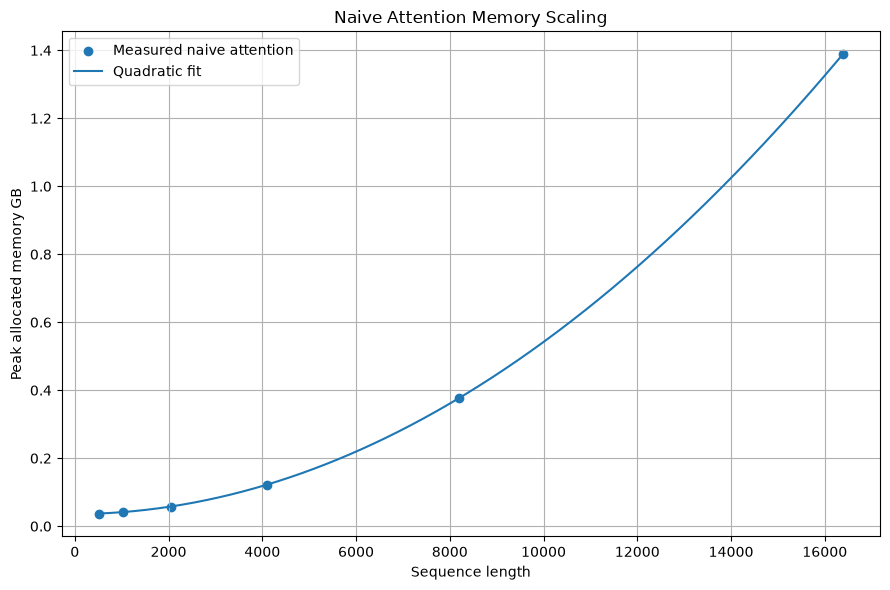

In [37]:
x_fit = np.linspace(
    x.min(),
    x.max(),
    500
)

y_fit = (
    a_quad * x_fit ** 2
    + b_linear * x_fit
    + c_constant
)

plt.figure(figsize=(9, 6))

plt.scatter(
    x,
    y,
    label="Measured naive attention"
)

plt.plot(
    x_fit,
    y_fit,
    label="Quadratic fit"
)

plt.xlabel(
    "Sequence length"
)

plt.ylabel(
    "Peak allocated memory GB"
)

plt.title(
    "Naive Attention Memory Scaling"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "part_d_naive_attention_memory_fit.png",
    dpi=200
)

plt.show()

In [38]:
comparison_df = pd.merge(
    naive_attention_df[
        [
            "sequence_length",
            "median_latency_ms",
            "peak_memory_gb",
            "success",
        ]
    ].rename(
        columns={
            "median_latency_ms":
                "naive_latency_ms",
            "peak_memory_gb":
                "naive_peak_memory_gb",
            "success":
                "naive_success",
        }
    ),
    fused_attention_df[
        [
            "sequence_length",
            "median_latency_ms",
            "peak_memory_gb",
            "success",
        ]
    ].rename(
        columns={
            "median_latency_ms":
                "fused_latency_ms",
            "peak_memory_gb":
                "fused_peak_memory_gb",
            "success":
                "fused_success",
        }
    ),
    on="sequence_length",
    how="outer"
)

comparison_df[
    "speedup"
] = (
    comparison_df[
        "naive_latency_ms"
    ]
    / comparison_df[
        "fused_latency_ms"
    ]
)

comparison_df.to_csv(
    OUTPUT_DIR
    / "part_d_attention_comparison.csv",
    index=False
)

comparison_df

,sequence_length,naive_latency_ms,naive_peak_memory_gb,naive_success,fused_latency_ms,fused_peak_memory_gb,fused_success,speedup
0,512,0.587280,0.037290,True,0.051296,0.035979,True,11.448846
1,1024,0.175360,0.041550,True,0.105008,0.036307,True,1.669968
2,2048,0.179792,0.057934,True,0.121328,0.036962,True,1.481867
3,4096,0.229184,0.122159,True,0.206800,0.038273,True,1.108240
4,8192,1.162256,0.376439,True,0.374944,0.040894,True,3.099812
5,16384,4.634432,1.388315,True,0.982576,0.046137,True,4.716614


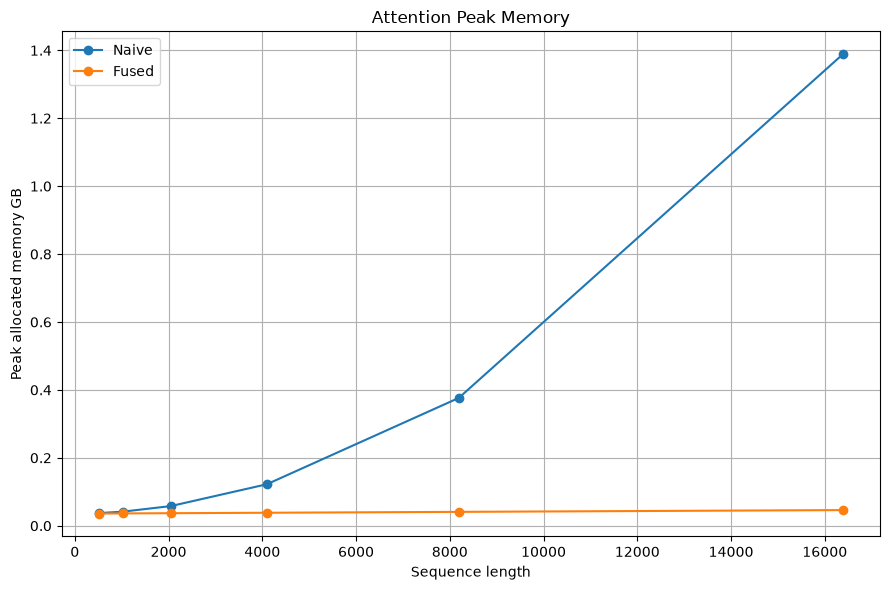

In [39]:
plt.figure(figsize=(9, 6))

plt.plot(
    naive_attention_df[
        "sequence_length"
    ],
    naive_attention_df[
        "peak_memory_gb"
    ],
    marker="o",
    label="Naive"
)

plt.plot(
    fused_attention_df[
        "sequence_length"
    ],
    fused_attention_df[
        "peak_memory_gb"
    ],
    marker="o",
    label="Fused"
)

plt.xlabel(
    "Sequence length"
)

plt.ylabel(
    "Peak allocated memory GB"
)

plt.title(
    "Attention Peak Memory"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "part_d_attention_memory_comparison.png",
    dpi=200
)

plt.show()

In [40]:
THERMAL_DURATION_SECONDS = 20 * 60
THERMAL_SAMPLE_INTERVAL_SECONDS = 5

thermal_log_path = (
    OUTPUT_DIR / "thermal_log.csv"
)

thermal_fields = [
    "timestamp",
    "elapsed_s",
    "gpu_uuid",
    "gpu_clock_mhz",
    "memory_clock_mhz",
    "temperature_c",
    "power_draw_w",
    "power_limit_w",
    "utilization_gpu_percent",
]

In [41]:
def query_gpu_telemetry():
    result = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu="
            "timestamp,"
            "clocks.gr,"
            "clocks.mem,"
            "temperature.gpu,"
            "power.draw,"
            "power.limit,"
            "utilization.gpu",
            "--format=csv,noheader,nounits",
        ],
        capture_output=True,
        text=True,
        check=True
    )

    values = [
        item.strip()
        for item
        in result.stdout.strip().split(",")
    ]

    return {
        "timestamp": values[0],
        "gpu_clock_mhz": float(
            values[1]
        ),
        "memory_clock_mhz": float(
            values[2]
        ),
        "temperature_c": float(
            values[3]
        ),
        "power_draw_w": float(
            values[4]
        ),
        "power_limit_w": float(
            values[5]
        ),
        "utilization_gpu_percent": float(
            values[6]
        ),
    }

In [42]:
def sustained_matmul_worker():
    n = 8192

    a = torch.randn(
        n,
        n,
        device=device,
        dtype=torch.float16
    )

    b = torch.randn(
        n,
        n,
        device=device,
        dtype=torch.float16
    )

    return a, b

In [43]:
a_thermal, b_thermal = sustained_matmul_worker()

thermal_rows = []
throughput_rows = []

start_wall = time.time()

next_sample_time = 0.0

while True:
    elapsed = (
        time.time()
        - start_wall
    )

    if elapsed >= THERMAL_DURATION_SECONDS:
        break

    start_event = torch.cuda.Event(
        enable_timing=True
    )

    end_event = torch.cuda.Event(
        enable_timing=True
    )

    start_event.record()

    c_thermal = torch.matmul(
        a_thermal,
        b_thermal
    )

    end_event.record()

    cuda_sync()

    matmul_ms = (
        start_event.elapsed_time(
            end_event
        )
    )

    flops = 2.0 * (8192 ** 3)

    tflops = (
        flops
        / (matmul_ms / 1000.0)
        / 1e12
    )

    throughput_rows.append(
        {
            "elapsed_s": elapsed,
            "tflops": tflops,
        }
    )

    if elapsed >= next_sample_time:
        telemetry = (
            query_gpu_telemetry()
        )

        telemetry[
            "elapsed_s"
        ] = elapsed

        telemetry[
            "gpu_uuid"
        ] = gpu_uuid

        thermal_rows.append(
            telemetry
        )

        print(
            f"{elapsed:.1f}s",
            telemetry
        )

        next_sample_time += (
            THERMAL_SAMPLE_INTERVAL_SECONDS
        )

0.0s {'timestamp': '2026/09/22 13:33:11.610', 'gpu_clock_mhz': 772.0, 'memory_clock_mhz': 7001.0, 'temperature_c': 50.0, 'power_draw_w': 38.53, 'power_limit_w': 575.0, 'utilization_gpu_percent': 1.0, 'elapsed_s': 0.0, 'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517'}
5.0s {'timestamp': '2026/09/22 13:33:16.617', 'gpu_clock_mhz': 2565.0, 'memory_clock_mhz': 13801.0, 'temperature_c': 68.0, 'power_draw_w': 574.78, 'power_limit_w': 575.0, 'utilization_gpu_percent': 98.0, 'elapsed_s': 5.004148721694946, 'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517'}
10.0s {'timestamp': '2026/09/22 13:33:21.615', 'gpu_clock_mhz': 2550.0, 'memory_clock_mhz': 13801.0, 'temperature_c': 70.0, 'power_draw_w': 575.35, 'power_limit_w': 575.0, 'utilization_gpu_percent': 98.0, 'elapsed_s': 10.004037857055664, 'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517'}
15.0s {'timestamp': '2026/09/22 13:33:26.617', 'gpu_clock_mhz': 2542.0, 'memory_clock_mhz': 13801.0, 'temperature_c': 71.0, 'power_draw_w': 

In [44]:
del a_thermal
del b_thermal
del c_thermal

clear_gpu()

thermal_df = pd.DataFrame(
    thermal_rows
)

throughput_df = pd.DataFrame(
    throughput_rows
)

thermal_df.to_csv(
    OUTPUT_DIR / "thermal_log.csv",
    index=False
)

throughput_df.to_csv(
    OUTPUT_DIR
    / "thermal_throughput.csv",
    index=False
)

thermal_df.head()

,timestamp,gpu_clock_mhz,memory_clock_mhz,temperature_c,power_draw_w,power_limit_w,utilization_gpu_percent,elapsed_s,gpu_uuid
0,2026/09/22 13:33:11.610,772.0,7001.0,50.0,38.53,575.0,1.0,0.000000,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
1,2026/09/22 13:33:16.617,2565.0,13801.0,68.0,574.78,575.0,98.0,5.004149,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
2,2026/09/22 13:33:21.615,2550.0,13801.0,70.0,575.35,575.0,98.0,10.004038,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
3,2026/09/22 13:33:26.617,2542.0,13801.0,71.0,573.67,575.0,98.0,15.001369,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
4,2026/09/22 13:33:31.615,2587.0,13801.0,72.0,575.57,575.0,98.0,20.003907,GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517


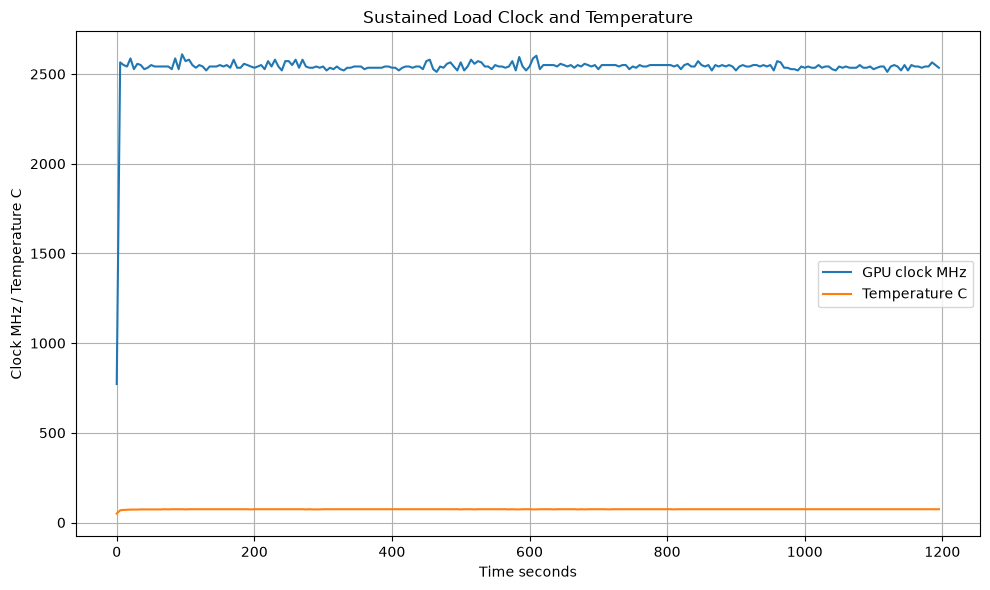

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    thermal_df["elapsed_s"],
    thermal_df["gpu_clock_mhz"],
    label="GPU clock MHz"
)

plt.plot(
    thermal_df["elapsed_s"],
    thermal_df["temperature_c"],
    label="Temperature C"
)

plt.xlabel(
    "Time seconds"
)

plt.ylabel(
    "Clock MHz / Temperature C"
)

plt.title(
    "Sustained Load Clock and Temperature"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "part_e_clock_temperature.png",
    dpi=200
)

plt.show()

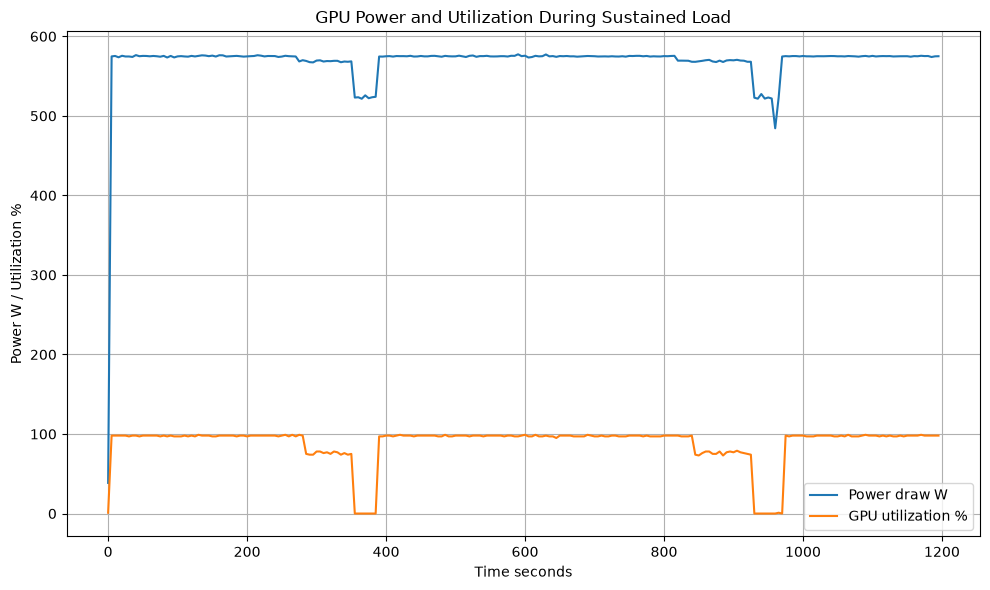

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    thermal_df["elapsed_s"],
    thermal_df["power_draw_w"],
    label="Power draw W"
)

plt.plot(
    thermal_df["elapsed_s"],
    thermal_df["utilization_gpu_percent"],
    label="GPU utilization %"
)

plt.xlabel("Time seconds")
plt.ylabel("Power W / Utilization %")
plt.title("GPU Power and Utilization During Sustained Load")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "part_e_power_utilization.png",
    dpi=200
)

plt.show()

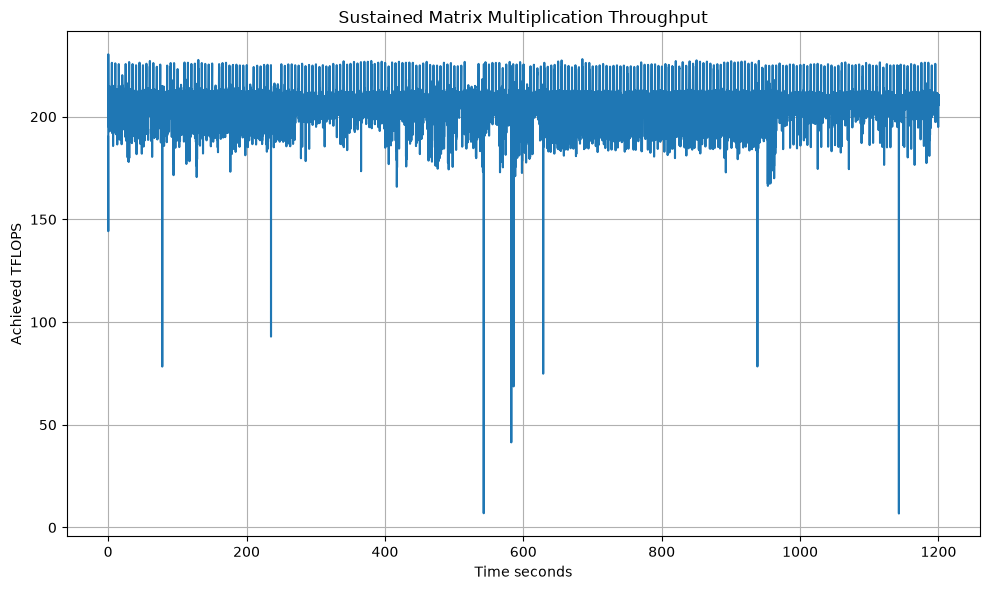

In [47]:

plt.figure(figsize=(10, 6))

plt.plot(
    throughput_df["elapsed_s"],
    throughput_df["tflops"]
)

plt.xlabel("Time seconds")
plt.ylabel("Achieved TFLOPS")
plt.title("Sustained Matrix Multiplication Throughput")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "part_e_throughput_over_time.png",
    dpi=200
)

plt.show()

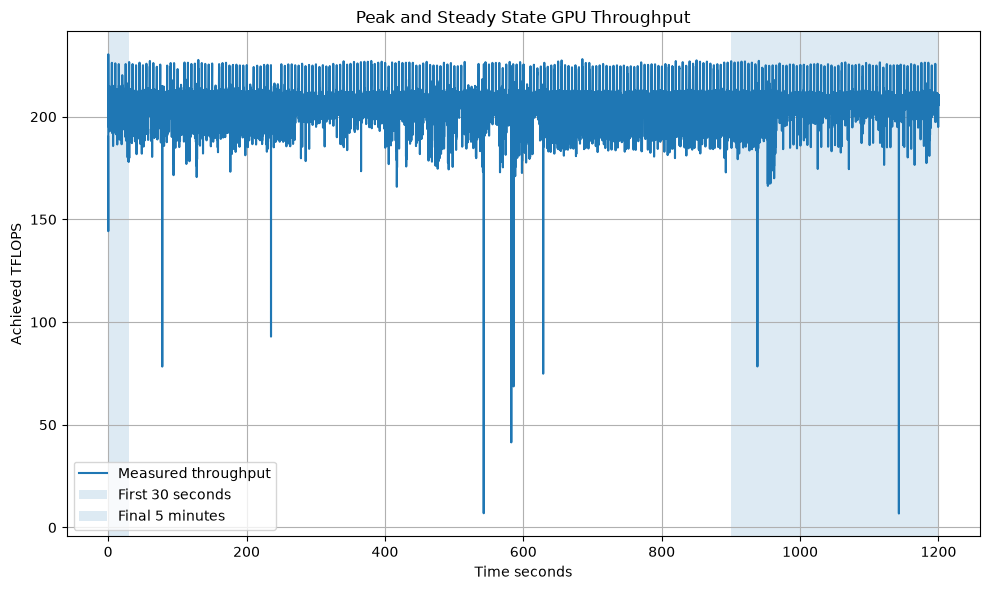

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    throughput_df["elapsed_s"],
    throughput_df["tflops"],
    label="Measured throughput"
)

plt.axvspan(
    0,
    30,
    alpha=0.15,
    label="First 30 seconds"
)

plt.axvspan(
    THERMAL_DURATION_SECONDS - 300,
    THERMAL_DURATION_SECONDS,
    alpha=0.15,
    label="Final 5 minutes"
)

plt.xlabel("Time seconds")
plt.ylabel("Achieved TFLOPS")
plt.title("Peak and Steady State GPU Throughput")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "part_e_peak_vs_steady_state.png",
    dpi=200
)

plt.show()

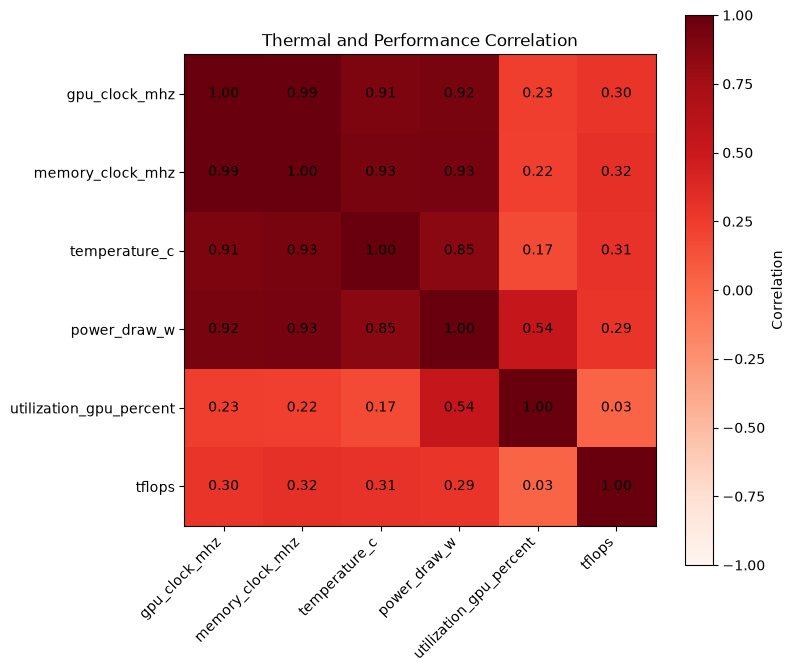

In [59]:
combined_df = pd.merge_asof(
    thermal_df.sort_values("elapsed_s"),
    throughput_df.sort_values("elapsed_s"),
    on="elapsed_s",
    direction="nearest"
)

columns = [
    "gpu_clock_mhz",
    "memory_clock_mhz",
    "temperature_c",
    "power_draw_w",
    "utilization_gpu_percent",
    "tflops"
]

correlation_matrix = combined_df[columns].corr()

plt.figure(figsize=(8, 7))

plt.imshow(
    correlation_matrix,
    cmap="Reds",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(columns)),
    columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columns)),
    columns
)

for i in range(len(columns)):
    for j in range(len(columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Thermal and Performance Correlation")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "part_e_correlation_heatmap.png",
    dpi=200
)

plt.show()

In [50]:
first_30s = throughput_df[
    throughput_df[
        "elapsed_s"
    ] <= 30
]

final_5min = throughput_df[
    throughput_df[
        "elapsed_s"
    ] >= (
        THERMAL_DURATION_SECONDS
        - 300
    )
]

peak_first_30s_tflops = (
    first_30s[
        "tflops"
    ].max()
)

steady_state_tflops = (
    final_5min[
        "tflops"
    ].mean()
)

steady_state_percent_peak = (
    steady_state_tflops
    / peak_first_30s_tflops
    * 100.0
)

print(
    "Peak throughput first 30 s:",
    peak_first_30s_tflops
)

print(
    "Mean throughput final 5 min:",
    steady_state_tflops
)

print(
    "Steady state / peak percent:",
    steady_state_percent_peak
)

Peak throughput first 30 s: 230.36262296928606
Mean throughput final 5 min: 209.14433278137076
Steady state / peak percent: 90.78917842034457


In [71]:
analysis_thermal_df = thermal_df[
    thermal_df["elapsed_s"] >= 60
].copy()

analysis_thermal_df[
    "power_fraction"
] = (
    analysis_thermal_df[
        "power_draw_w"
    ]
    / analysis_thermal_df[
        "power_limit_w"
    ]
)

baseline_window = analysis_thermal_df[
    (
        analysis_thermal_df["elapsed_s"] >= 60
    )
    &
    (
        analysis_thermal_df["elapsed_s"] <= 180
    )
]

clock_baseline = baseline_window[
    "gpu_clock_mhz"
].median()

analysis_thermal_df[
    "clock_drop_fraction"
] = (
    analysis_thermal_df[
        "gpu_clock_mhz"
    ]
    / clock_baseline
)

potential_throttle = analysis_thermal_df[
    (
        analysis_thermal_df[
            "clock_drop_fraction"
        ] <= 0.90
    )
    &
    (
        analysis_thermal_df[
            "utilization_gpu_percent"
        ] >= 90
    )
]

if len(potential_throttle) > 0:
    throttle_row = potential_throttle.iloc[0]

    throttle_onset_s = float(
        throttle_row["elapsed_s"]
    )

    throttle_temp_c = float(
        throttle_row["temperature_c"]
    )

    throttle_power_w = float(
        throttle_row["power_draw_w"]
    )

    print(
        "Throttle onset:",
        throttle_onset_s,
        "seconds"
    )

    print(
        "Temperature at onset:",
        throttle_temp_c,
        "C"
    )

    print(
        "Power at onset:",
        throttle_power_w,
        "W"
    )

else:
    throttle_onset_s = None

    print(
        "No clock throttling detected during sustained load."
    )

print(
    "Baseline sustained GPU clock:",
    clock_baseline,
    "MHz"
)

print(
    "Maximum temperature:",
    analysis_thermal_df["temperature_c"].max(),
    "C"
)

print(
    "Maximum power draw:",
    analysis_thermal_df["power_draw_w"].max(),
    "W"
)

No clock throttling detected during sustained load.
Baseline sustained GPU clock: 2542.0 MHz
Maximum temperature: 74.0 C
Maximum power draw: 577.44 W


In [72]:
peak_bf16_row = (
    matmul_df[
        matmul_df[
            "precision"
        ] == "BF16"
    ]
    .sort_values(
        "achieved_tflops",
        ascending=False
    )
    .iloc[0]
)

summary_table = pd.DataFrame(
    [
        {
            "Measurement":
                "Peak achieved TFLOPS BF16",
            "Your GPU":
                peak_bf16_row[
                    "achieved_tflops"
                ],
            "Notes":
                f"N={int(peak_bf16_row['N'])}, UUID={gpu_uuid}",
        },
        {
            "Measurement":
                "% of theoretical peak BF16",
            "Your GPU":
                peak_bf16_row[
                    "percent_peak"
                ],
            "Notes":
                f"Theoretical={THEORETICAL_TFLOPS['BF16']} TFLOPS",
        },
        {
            "Measurement":
                "Effective bandwidth GB/s",
            "Your GPU":
                memory_result[
                    "effective_bandwidth_gb_s"
                ],
            "Notes":
                f"{memory_result['percent_spec_bandwidth']:.2f}% of specification",
        },
        {
            "Measurement":
                "Naive attention largest success",
            "Your GPU":
                naive_oom_boundary[
                    "largest_success"
                ],
            "Notes":
                f"Smallest failure={naive_oom_boundary['smallest_failure']}",
        },
        {
            "Measurement":
                "Fused attention largest success",
            "Your GPU":
                fused_oom_boundary[
                    "largest_success"
                ],
            "Notes":
                f"Smallest failure={fused_oom_boundary['smallest_failure']}",
        },
        {
            "Measurement":
                "Steady state / peak throughput",
            "Your GPU":
                steady_state_percent_peak,
            "Notes":
                "Percent",
        },
        {
            "Measurement":
                "Throttle onset",
            "Your GPU":
                (
                    throttle_onset_s
                    if throttle_onset_s
                    is not None
                    else "none"
                ),
            "Notes":
                "seconds",
        },
    ]
)

summary_table

,Measurement,Your GPU,Notes
0,Peak achieved TFLOPS BF16,219.046206,"N=16384, UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0..."
1,% of theoretical peak BF16,52.278331,Theoretical=419.0 TFLOPS
2,Effective bandwidth GB/s,1502.259259,83.83% of specification
3,Naive attention largest success,117248,Smallest failure=117504
4,Fused attention largest success,524288,Smallest failure=None
5,Steady state / peak throughput,90.789178,Percent
6,Throttle onset,none,seconds


In [73]:
summary_table.to_csv(
    OUTPUT_DIR
    / "part_f_summary_table.csv",
    index=False
)

In [79]:
from pathlib import Path
import inspect

BASE_DIR = Path("GPU Assignment 1")
BASE_DIR.mkdir(parents=True, exist_ok=True)

benchmark_functions = [
    cuda_sync,
    clear_gpu,
    benchmark_matmul,
    benchmark_memory_copy,
    arithmetic_intensity_copy,
    arithmetic_intensity_add,
    arithmetic_intensity_matmul,
    naive_attention,
    fused_attention,
    benchmark_attention,
    attention_can_run,
    refine_oom_boundary,
    query_gpu_telemetry,
    sustained_matmul_worker,
]

header = '''import gc
import math
import subprocess

import numpy as np
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

'''

source_blocks = []

for fn in benchmark_functions:
    source_blocks.append(inspect.getsource(fn))

benchmark_file = BASE_DIR / "benchmark.py"

with open(benchmark_file, "w", encoding="utf-8") as f:
    f.write(header)
    f.write("\n\n".join(source_blocks))

print("Created:", benchmark_file)

Created: GPU Assignment 1\benchmark.py


In [74]:
metrics_lines = []

metrics_lines.append(
    "# METRICS"
)

metrics_lines.append("")
metrics_lines.append(
    f"GPU UUID: `{gpu_uuid}`"
)

metrics_lines.append("")
metrics_lines.append(
    f"GPU: `{gpu_name}`"
)

metrics_lines.append("")
metrics_lines.append(
    "## Table HW2.5.1"
)

metrics_lines.append("")
metrics_lines.append(
    "| Measurement | Your GPU | Notes |"
)

metrics_lines.append(
    "| --- | ---: | --- |"
)

for _, row in summary_table.iterrows():
    metrics_lines.append(
        f"| {row['Measurement']} | "
        f"{row['Your GPU']} | "
        f"{row['Notes']} |"
    )

with open(
    OUTPUT_DIR / "METRICS.md",
    "w"
) as f:
    f.write(
        "\n".join(
            metrics_lines
        )
    )

print(
    "\n".join(
        metrics_lines
    )
)

# METRICS

GPU UUID: `GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517`

GPU: `NVIDIA GeForce RTX 5090`

## Table HW2.5.1

| Measurement | Your GPU | Notes |
| --- | ---: | --- |
| Peak achieved TFLOPS BF16 | 219.04620628971344 | N=16384, UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 |
| % of theoretical peak BF16 | 52.27833085673351 | Theoretical=419.0 TFLOPS |
| Effective bandwidth GB/s | 1502.2592589564472 | 83.83% of specification |
| Naive attention largest success | 117248 | Smallest failure=117504 |
| Fused attention largest success | 524288 | Smallest failure=None |
| Steady state / peak throughput | 90.78917842034457 | Percent |
| Throttle onset | none | seconds |


In [75]:
run_log_lines = []

run_log_lines.append(
    "HW2.5 GPU Assignment Run Log"
)

run_log_lines.append(
    f"GPU UUID: {gpu_uuid}"
)

run_log_lines.append(
    f"GPU Name: {gpu_name}"
)

run_log_lines.append(
    f"Driver: {driver_version}"
)

run_log_lines.append(
    f"CUDA Runtime: {torch.version.cuda}"
)

run_log_lines.append("")
run_log_lines.append(
    "PART B"
)

for _, row in matmul_df.iterrows():
    run_log_lines.append(
        f"UUID={gpu_uuid} "
        f"N={int(row['N'])} "
        f"precision={row['precision']} "
        f"median_ms={row['median_ms']:.6f} "
        f"TFLOPS={row['achieved_tflops']:.4f} "
        f"percent_peak={row['percent_peak']:.2f}"
    )

run_log_lines.append("")
run_log_lines.append(
    "PART C"
)

run_log_lines.append(
    f"UUID={gpu_uuid} "
    f"effective_bandwidth_gb_s="
    f"{memory_result['effective_bandwidth_gb_s']:.4f}"
)

run_log_lines.append("")
run_log_lines.append(
    "PART D"
)

for _, row in comparison_df.iterrows():
    run_log_lines.append(
        f"UUID={gpu_uuid} "
        f"sequence_length={int(row['sequence_length'])} "
        f"naive_ms={row['naive_latency_ms']} "
        f"fused_ms={row['fused_latency_ms']} "
        f"speedup={row['speedup']}"
    )

run_log_lines.append("")
run_log_lines.append(
    f"Naive OOM boundary: "
    f"{naive_oom_boundary}"
)

run_log_lines.append(
    f"Fused OOM boundary: "
    f"{fused_oom_boundary}"
)

run_log_lines.append("")
run_log_lines.append(
    "PART E"
)

run_log_lines.append(
    f"Peak first 30 seconds TFLOPS: "
    f"{peak_first_30s_tflops}"
)

run_log_lines.append(
    f"Final 5 minute mean TFLOPS: "
    f"{steady_state_tflops}"
)

run_log_lines.append(
    f"Steady state percent peak: "
    f"{steady_state_percent_peak}"
)

run_log_lines.append(
    f"Throttle onset seconds: "
    f"{throttle_onset_s}"
)

with open(
    OUTPUT_DIR / "RUN_LOG.txt",
    "w"
) as f:
    f.write(
        "\n".join(
            run_log_lines
        )
    )

print(
    "\n".join(
        run_log_lines
    )
)

HW2.5 GPU Assignment Run Log
GPU UUID: GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517
GPU Name: NVIDIA GeForce RTX 5090
Driver: 610.60
CUDA Runtime: 13.2

PART B
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=1024 precision=FP32 median_ms=0.067136 TFLOPS=31.9871 percent_peak=30.52
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=4096 precision=FP32 median_ms=2.112096 TFLOPS=65.0723 percent_peak=62.09
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=8192 precision=FP32 median_ms=16.584144 TFLOPS=66.2990 percent_peak=63.26
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=16384 precision=FP32 median_ms=133.488098 TFLOPS=65.8942 percent_peak=62.88
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=1024 precision=TF32 median_ms=0.117696 TFLOPS=18.2460 percent_peak=8.71
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=4096 precision=TF32 median_ms=1.382592 TFLOPS=99.4067 percent_peak=47.45
UUID=GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517 N=8192 precision=TF32 median_ms=9.770976 TFLOPS=112.5283 percent_peak

In [78]:
reservation_record = {
    "gpu_uuid": gpu_uuid,
    "gpu_name": gpu_name,
    "reservation_start": "1pm",
    "reservation_end": "2:35pm",
    "reserved_gpu_hours": "2",
    "actual_gpu_hours_used": "2",
}

with open(
    OUTPUT_DIR
    / "reservation_gpu_hours.json",
    "w"
) as f:
    json.dump(
        reservation_record,
        f,
        indent=4
    )

reservation_record

{'gpu_uuid': 'GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517',
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'reservation_start': '1pm',
 'reservation_end': '2:35pm',
 'reserved_gpu_hours': '2',
 'actual_gpu_hours_used': '2'}

In [77]:
print(
    "Files created:"
)

for path in sorted(
    OUTPUT_DIR.iterdir()
):
    print(path)

Files created:
hw2_5_outputs\METRICS.md
hw2_5_outputs\nvidia_smi_q.txt
hw2_5_outputs\part_b_lower_precision_test.json
hw2_5_outputs\part_b_matmul_results.csv
hw2_5_outputs\part_b_tflops_vs_matrix_size.png
hw2_5_outputs\part_c_roofline_results.csv
hw2_5_outputs\part_d_attention_comparison.csv
hw2_5_outputs\part_d_attention_memory_comparison.png
hw2_5_outputs\part_d_fused_attention.csv
hw2_5_outputs\part_d_naive_attention.csv
hw2_5_outputs\part_d_naive_attention_memory_fit.png
hw2_5_outputs\part_e_clock_temperature.png
hw2_5_outputs\part_e_correlation_heatmap.png
hw2_5_outputs\part_e_peak_vs_steady_state.png
hw2_5_outputs\part_e_power_utilization.png
hw2_5_outputs\part_e_throughput_over_time.png
hw2_5_outputs\part_f_summary_table.csv
hw2_5_outputs\provenance.json
hw2_5_outputs\reservation_gpu_hours.json
hw2_5_outputs\RUN_LOG.txt
hw2_5_outputs\thermal_log.csv
hw2_5_outputs\thermal_throughput.csv
